In [6]:
import mne
import numpy as np
import matplotlib.pyplot as plt

In [9]:
sample_data_folder = mne.datasets.sample.data_path()
raw_file = sample_data_folder / "MEG" / "sample" / "sample_audvis_raw.fif"
raw = mne.io.read_raw_fif(raw_file, preload=True)


Opening raw data file /Users/anushka.j/mne_data/MNE-sample-data/MEG/sample/sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.
Reading 0 ... 166799  =      0.000 ...   277.714 secs...


In [10]:
events = mne.find_events(raw, stim_channel="STI 014")

Finding events on: STI 014
320 events found on stim channel STI 014
Event IDs: [ 1  2  3  4  5 32]


In [11]:
raw.pick("eeg")
raw.filter(l_freq=1, h_freq=40)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1983 samples (3.302 s)



<Raw | sample_audvis_raw.fif, 60 x 166800 (277.7 s), ~79.3 MiB, data loaded>

In [12]:
event_dict = {"auditory/left": 1, "auditory/right": 2, "visual/left": 3, "visual/right": 4}
epochs = mne.Epochs(raw, events, event_id=event_dict, tmin=-0.2, tmax=0.5,
baseline=(-0.2, 0), preload=True)

Not setting metadata
289 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 289 events and 421 original time points ...
0 bad epochs dropped


In [16]:
evoked_auditory = epochs["auditory"].average()
evoked_visual = epochs["visual"].average()

In [17]:
aud_ch, aud_time, aud_amp = evoked_auditory.get_peak(
ch_type="eeg", return_amplitude=True
)
print("AUDITORY:")
print(f"  Peak channel: {aud_ch}")
print(f"  Peak time: {aud_time:.3f} s")
print(f"  Peak amplitude: {aud_amp:.2e}")


AUDITORY:
  Peak channel: EEG 007
  Peak time: 0.095 s
  Peak amplitude: -1.09e-05


In [18]:
vis_ch, vis_time, vis_amp = evoked_visual.get_peak(
    ch_type="eeg", return_amplitude=True
)
print("\nVISUAL:")
print(f"  Peak channel: {vis_ch}")
print(f"  Peak time: {vis_time:.3f} s")
print(f"  Peak amplitude: {vis_amp:.2e}")


VISUAL:
  Peak channel: EEG 056
  Peak time: 0.175 s
  Peak amplitude: -1.18e-05


In [22]:
time_difference = vis_time - aud_time

print("QUANTITATIVE COMPARISON")
print()
print(f"Auditory peak time: {aud_time:.3f} s")
print(f"Visual peak time:   {vis_time:.3f} s")
print(f"Difference:         {time_difference:.3f} s")
print()
if aud_time < vis_time:
    print(f"The auditory response peaks {time_difference*1000:.0f} ms earlier than the visual response.")
else:
    print(f"The visual response peaks {abs(time_difference)*1000:.0f} ms earlier than the auditory response.")

QUANTITATIVE COMPARISON

Auditory peak time: 0.095 s
Visual peak time:   0.175 s
Difference:         0.080 s

The auditory response peaks 80 ms earlier than the visual response.


combining channels using GFP (eeg channels)
combining channels using GFP (eeg channels)


Text(0.5, 1.0, 'Auditory vs Visual: Peak Timing Comparison')

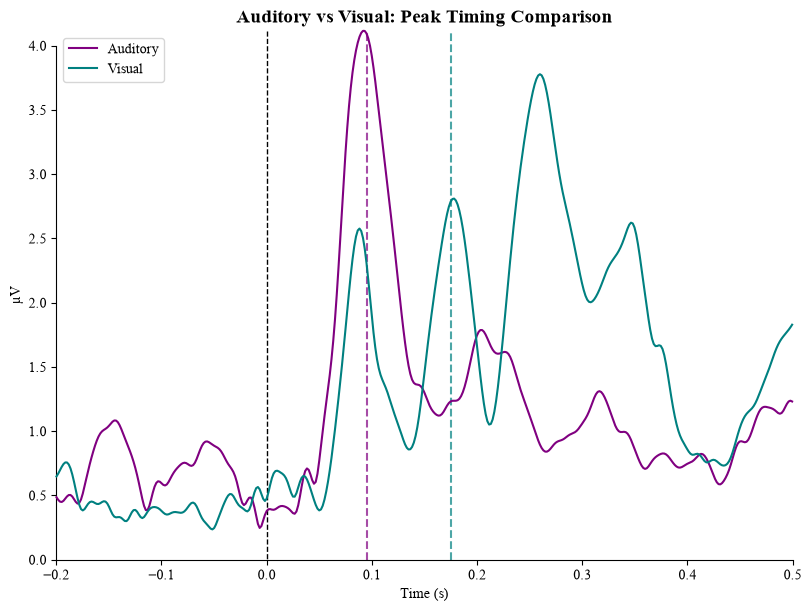

In [26]:
import matplotlib as mpl
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = ["Times New Roman", "DejaVu Serif"]

my_colors = {
"Auditory": "#800080",   # deep blue
"Visual":   "#008080",
}

fig = mne.viz.plot_compare_evokeds(
{"Auditory": evoked_auditory, "Visual": evoked_visual},
colors=my_colors,        
show=False
)[0]

ax = fig.axes[0]

ax.axvline(aud_time, color="#800080", linestyle="--", alpha=0.7)
ax.axvline(vis_time, color="#008080", linestyle="--", alpha=0.7)
ax.set_title("Auditory vs Visual: Peak Timing Comparison",
color="#000000", fontsize=14, weight="bold")




In [27]:
fig.savefig("condition_comparison.png", dpi=300, bbox_inches="tight")
plt.show()